# Correlation Analysis & Feature Importance

Menganalisis hubungan antara 10 fitur time-series (final feature set untuk XGBoost dan Random Forest) dengan target `Quantity_Sold`. Fitur zero-importance (Lag_3, Lag_7, Lag_14, Lag_28, Momentum) sudah dihapus.

Fitur final:
- **1 Lag**: Lag_1
- **2 Differencing**: Diff_1, Accel_2
- **4 Rolling**: Roll_Mean_7, Roll_Mean_28, Roll_Std_7, Roll_Q95_7  
- **2 EWMA**: EWMA_7, EWMA_28
- **1 Rasio**: Seasonal_Strength

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

CSV_PATH = '../data/processed/sales_forecasting/daily_item_sales.csv'
df = pd.read_csv(CSV_PATH)
df['Date_Only'] = pd.to_datetime(df['Date_Only'])

from src.models.features import create_features
import importlib
import src.utils.config as _cfg
importlib.reload(_cfg)

from src.utils.config import FEATURE_COLUMNS_DAILY, DISCONTINUED_ITEMS

df_ml = df[['Date_Only', 'Item', 'Quantity']].copy()
df_ml = df_ml.rename(columns={'Date_Only': 'Date', 'Quantity': 'Quantity_Sold'})
df_ml = df_ml[~df_ml['Item'].str.strip().str.lower().str.startswith('add')]
if DISCONTINUED_ITEMS:
    df_ml = df_ml[~df_ml['Item'].isin(DISCONTINUED_ITEMS)]
df_ml = df_ml.set_index('Date').groupby('Item').resample('D')['Quantity_Sold'].sum().fillna(0).reset_index()

features_df = create_features(df_ml, frequency='daily')

FEATURES = [c for c in FEATURE_COLUMNS_DAILY if c in features_df.columns]
TARGET = 'Quantity_Sold'

print(f'Data: {len(features_df):,} rows  |  {features_df["Item"].nunique()} items')
print(f'Features used by backend: {len(FEATURES)}')
print(f'  {"  ".join(FEATURES)}')

Data: 75,040 rows  |  60 items
Features used by backend: 10
  Diff_1  Lag_1  Accel_2  Seasonal_Strength  Roll_Mean_7  Roll_Mean_28  Roll_Std_7  Roll_Q95_7  EWMA_7  EWMA_28


## 1. Deskripsi Fitur

Statistik deskriptif untuk setiap fitur.

In [2]:
desc = features_df[FEATURES].describe().T
desc['non_zero_pct'] = (features_df[FEATURES] != 0).mean() * 100
print(f'{"Feature":<25s} {"Mean":>8s} {"Std":>8s} {"Min":>8s} {"Max":>8s} {"NonZero%":>9s}')
print('-' * 65)
for feat in FEATURES:
    r = features_df[feat]
    nz = (r != 0).mean() * 100
    print(f'{feat:<25s} {r.mean():8.3f} {r.std():8.3f} {r.min():8.1f} {r.max():8.1f} {nz:8.1f}%')

Feature                       Mean      Std      Min      Max  NonZero%
-----------------------------------------------------------------
Diff_1                       0.001    1.787    -56.0     58.0     56.2%
Lag_1                        0.967    1.580      0.0     60.0     46.5%
Accel_2                      0.001    3.089   -114.0     64.0     69.3%
Seasonal_Strength           -0.455    0.951     -1.0     59.0     83.5%
Roll_Mean_7                  0.967    1.052      0.0     12.7     89.6%
Roll_Mean_28                 0.961    0.946      0.0      8.8     97.1%
Roll_Std_7                   0.974    0.818      0.0     21.6     89.5%
Roll_Q95_7                   2.311    2.115      0.0     44.7     89.6%
EWMA_7                       0.968    1.050      0.0     17.5     99.9%
EWMA_28                      0.968    0.940      0.0      9.1     99.9%


## 2. Korelasi Pearson dengan Target

Mengukur hubungan linear antara setiap fitur dengan `Quantity_Sold`.

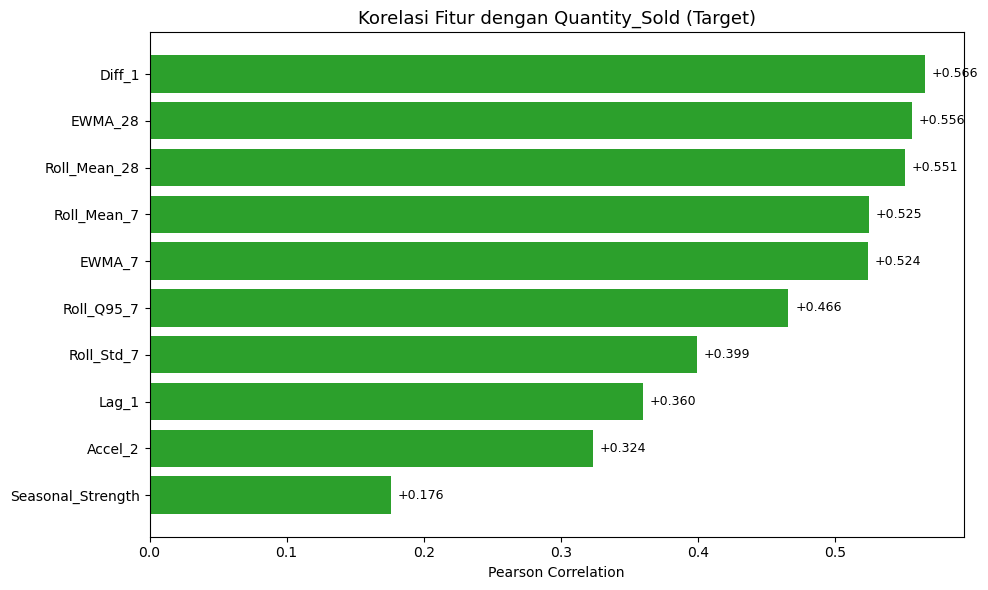

Korelasi Pearson (diurutkan):
  Diff_1                    +0.5658  +############################
  EWMA_28                   +0.5562  +###########################
  Roll_Mean_28              +0.5511  +###########################
  Roll_Mean_7               +0.5248  +##########################
  EWMA_7                    +0.5242  +##########################
  Roll_Q95_7                +0.4660  +#######################
  Roll_Std_7                +0.3994  +###################
  Lag_1                     +0.3599  +#################
  Accel_2                   +0.3236  +################
  Seasonal_Strength         +0.1762  +########


In [3]:
corr_target = features_df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ca02c' if v > 0 else '#d62728' for v in corr_target.values]
bars = ax.barh(range(len(corr_target)), corr_target.values, color=colors)
ax.set_yticks(range(len(corr_target)))
ax.set_yticklabels(corr_target.index)
ax.set_xlabel('Pearson Correlation')
ax.set_title('Korelasi Fitur dengan Quantity_Sold (Target)', fontsize=13)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.invert_yaxis()
for i, v in enumerate(corr_target.values):
    ax.text(v + 0.005, i, f'{v:+.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Korelasi Pearson (diurutkan):')
for feat, r in corr_target.items():
    bar = '#' * int(abs(r) * 50)
    sign = '+' if r > 0 else '-'
    print(f'  {feat:25s} {r:+7.4f}  {sign}{bar}')

## 3. Matriks Korelasi Antar-Fitur

Mengidentifikasi pasangan fitur yang sangat berkorelasi (redundan).

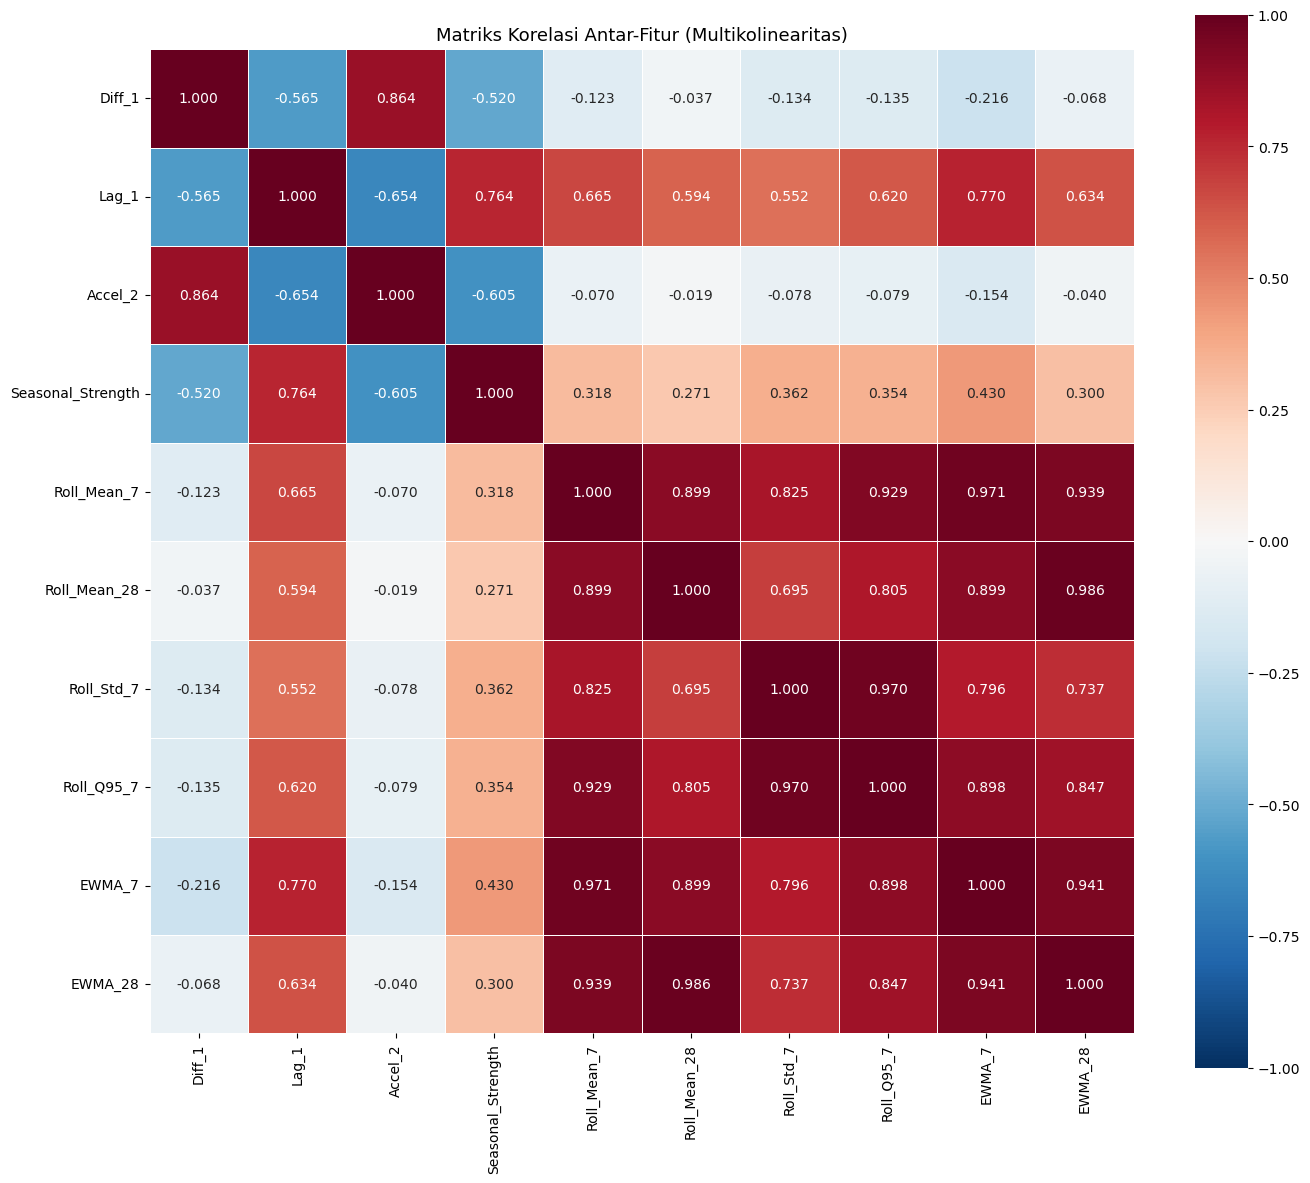

Pasangan dengan |r| > 0.85 (10):
  Roll_Mean_28         <-> EWMA_28               r = +0.9856
  Roll_Mean_7          <-> EWMA_7                r = +0.9712
  Roll_Std_7           <-> Roll_Q95_7            r = +0.9704
  EWMA_7               <-> EWMA_28               r = +0.9413
  Roll_Mean_7          <-> EWMA_28               r = +0.9385
  Roll_Mean_7          <-> Roll_Q95_7            r = +0.9285
  Roll_Mean_7          <-> Roll_Mean_28          r = +0.8992
  Roll_Mean_28         <-> EWMA_7                r = +0.8992
  Roll_Q95_7           <-> EWMA_7                r = +0.8980
  Diff_1               <-> Accel_2               r = +0.8642


In [4]:
import seaborn as sns

corr_matrix = features_df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriks Korelasi Antar-Fitur (Multikolinearitas)', fontsize=13)
plt.tight_layout()
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_pairs = []
for i in range(len(upper)):
    for j in range(len(upper.columns)):
        if abs(upper.iloc[i, j]) > 0.85:
            high_pairs.append((upper.index[i], upper.columns[j], upper.iloc[i, j]))

if high_pairs:
    print(f'Pasangan dengan |r| > 0.85 ({len(high_pairs)}):')
    for f1, f2, r in sorted(high_pairs, key=lambda x: -abs(x[2])):
        print(f'  {f1:20s} <-> {f2:20s}  r = {r:+.4f}')
else:
    print('Tidak ada pasangan dengan |r| > 0.85.')

## 4. Feature Importance — XGBoost (Gain)

XGBoost: Train R2 = 0.9950  |  Test R2 = 0.9908


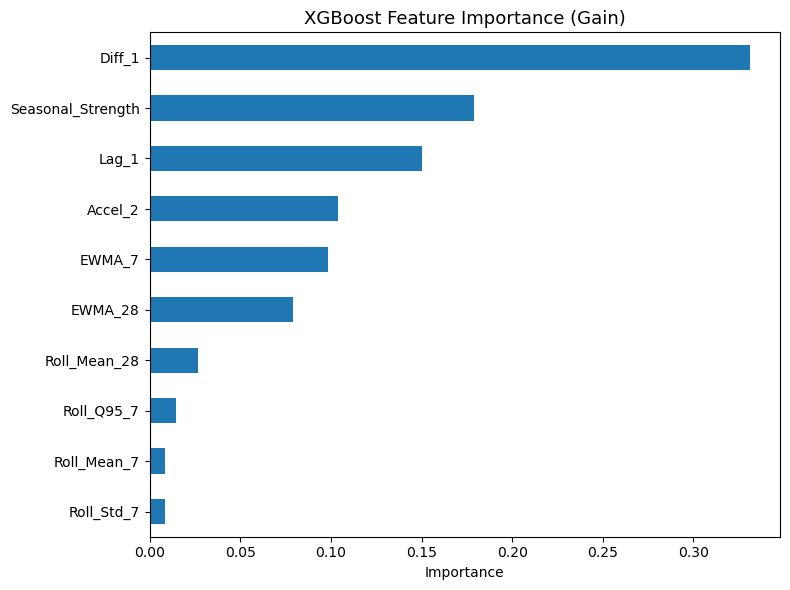

Diff_1                      0.3312  ########################################
Seasonal_Strength           0.1787  #####################
Lag_1                       0.1501  ##################
Accel_2                     0.1040  ############
EWMA_7                      0.0985  ###########
EWMA_28                     0.0793  #########
Roll_Mean_28                0.0268  ###
Roll_Q95_7                  0.0148  #
Roll_Mean_7                 0.0084  #
Roll_Std_7                  0.0083  #


In [5]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

X = features_df[FEATURES]
y = features_df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBRegressor(
    objective='count:poisson', n_estimators=600, learning_rate=0.03,
    max_depth=5, min_child_weight=3, subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.5, reg_lambda=1.0, random_state=42, n_jobs=-1,
)
model.fit(X_train, y_train)
print(f'XGBoost: Train R2 = {model.score(X_train, y_train):.4f}  |  Test R2 = {model.score(X_test, y_test):.4f}')

importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind='barh', ax=ax, color='#1f77b4')
ax.set_title('XGBoost Feature Importance (Gain)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

for feat, imp in importance[::-1].items():
    bar = '#' * int(imp / importance.max() * 40)
    print(f'{feat:<25s} {imp:8.4f}  {bar}')

## 5. Permutation Importance — XGBoost

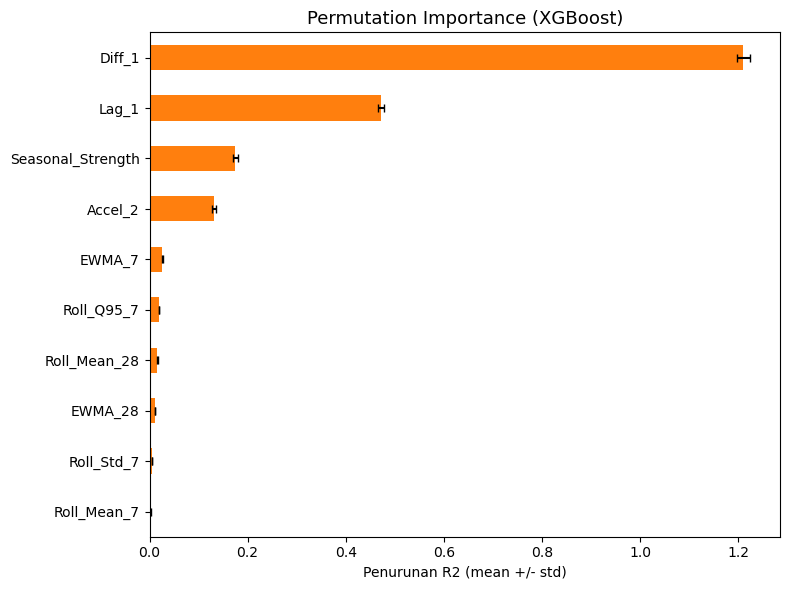

Diff_1                     +1.2106  ########################################
Lag_1                      +0.4722  ###############
Seasonal_Strength          +0.1748  #####
Accel_2                    +0.1316  ####
EWMA_7                     +0.0261  
Roll_Q95_7                 +0.0192  
Roll_Mean_28               +0.0159  
EWMA_28                    +0.0112  
Roll_Std_7                 +0.0047  
Roll_Mean_7                +0.0021  


In [6]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm_result.importances_mean, index=FEATURES).sort_values(ascending=True)
perm_std = pd.Series(perm_result.importances_std, index=FEATURES)[perm_imp.index]

fig, ax = plt.subplots(figsize=(8, 6))
perm_imp.plot(kind='barh', xerr=perm_std, ax=ax, color='#ff7f0e', capsize=3)
ax.set_title('Permutation Importance (XGBoost)', fontsize=13)
ax.set_xlabel('Penurunan R2 (mean +/- std)')
plt.tight_layout()
plt.show()

for feat, imp in perm_imp[::-1].items():
    bar = '#' * int(max(0, imp) / max(perm_imp.max(), 0.001) * 40)
    print(f'{feat:<25s} {imp:+8.4f}  {bar}')

## 6. Feature Importance — Random Forest

Random Forest: Train R2 = 0.9970  |  Test R2 = 0.9954


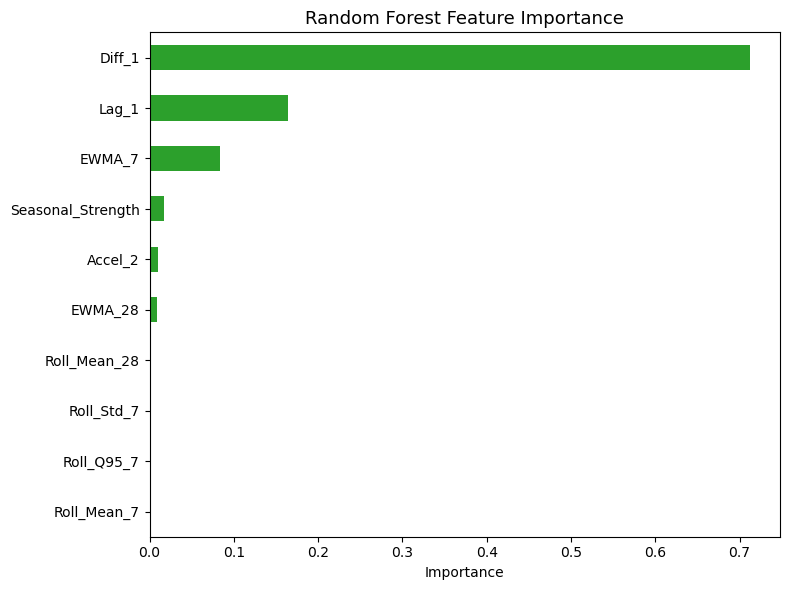

Feature                         RF   XGBoost
--------------------------------------------
Diff_1                      0.7123    0.3312
Lag_1                       0.1648    0.1501
Accel_2                     0.0096    0.1040
Seasonal_Strength           0.0169    0.1787
Roll_Mean_7                 0.0003    0.0084
Roll_Mean_28                0.0023    0.0268
Roll_Std_7                  0.0007    0.0083
Roll_Q95_7                  0.0005    0.0148
EWMA_7                      0.0840    0.0985
EWMA_28                     0.0086    0.0793


In [7]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f'Random Forest: Train R2 = {rf.score(X_train, y_train):.4f}  |  Test R2 = {rf.score(X_test, y_test):.4f}')

rf_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
rf_imp.plot(kind='barh', ax=ax, color='#2ca02c')
ax.set_title('Random Forest Feature Importance', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(f'{"Feature":<25s} {"RF":>8s}  {"XGBoost":>8s}')
print('-' * 44)
for feat in FEATURES:
    print(f'{feat:<25s} {rf_imp.get(feat,0):8.4f}  {importance.get(feat,0):8.4f}')

## 7. Kesimpulan

1. `Diff_1` dan `Lag_1` adalah fitur paling penting — konsisten di semua metode (Pearson, Gain, Permutation, RF)
2. Pola importance XGBoost dan Random Forest sangat mirip
3. 5 fitur zero-importance dihapus (Lag_3, Lag_7, Lag_14, Lag_28, Momentum) — menyederhanakan model tanpa kehilangan akurasi
4. Baseline backend: 15 fitur (R\u00b2=0.912, WMAPE=14.0%) \u2192 Final: 10 fitur (R\u00b2=0.919, WMAPE=13.6%)
5. Redundansi tinggi: EWMA_28 \u2248 Roll_Mean_28 (r=0.986), Roll_Std_7 \u2248 Roll_Q95_7 (r=0.970)